# Probability Paths in Flow Matching

A **probability path** $p_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1)$ defines how the
model finds where $\mathbf{x}_t$ between source $\mathbf{x}_0$ and target $\mathbf{x}_1$ during training.
Every path produces an intermediate state at time $t \in [0,1]$:

$$\mathbf{x}_t = \mu_t(\mathbf{x}_0, \mathbf{x}_1) + \sigma_t\,\boldsymbol{\epsilon}$$

Each path class exposes four methods:

| Method | Returns |
|---|---|
| `compute_mu_t(t, x0, x1)` | Mean $\mu_t$ |
| `compute_sigma_t(t)` | Noise std $\sigma_t$ |
| `compute_xt(t, x0, x1)` | Find position $\mathbf{x}_t$ at time t |
| `compute_ut(t, xt, x0, x1)` | Find velocity $u_t$ at time t |

**Summary of all four paths:**

| Path | $\mu_t$ | $\sigma_t$ | Stochastic | Parameters |
|---|---|---|---|---|
| `LinearDiracProbabilityPath` | $(1-t)\mathbf{x}_0 + t\mathbf{x}_1$ | $0$ | No | `sigma` (ignored) |
| `LinearGaussianProbabilityPath` | $(1-t)\mathbf{x}_0 + t\mathbf{x}_1$ | $\sigma$ | Yes | `sigma` |
| `SchrodingerBridgeProbabilityPath` | $(1-t)\mathbf{x}_0 + t\mathbf{x}_1$ | $\sigma\sqrt{t(1-t)}$ | Yes | `sigma`, `eps` |
| `VariancePreservingDiracProbabilityPath` | $\cos(\tfrac{\pi t}{2})\mathbf{x}_1 + \sin(\tfrac{\pi t}{2})\mathbf{x}_0$ | $0$ | No | `sigma` (ignored) |


In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sc_flow.backends.torch.probability_paths import (
    LinearGaussianProbabilityPath,
    LinearDiracProbabilityPath,
    SchrodingerBridgeProbabilityPath,
    VariancePreservingDiracProbabilityPath,
)
from sc_flow.dataset.toy_data import get_toy_dataset

## Data: Two-Moons Transport Task

A 2-D transport problem: move cells from the *bottom* moon (source $\mathbf{x}_0$)
to the *top* moon (target $\mathbf{x}_1$).  The pair $(\mathbf{x}_0, \mathbf{x}_1)$
defines one training sample.  All four paths are applied on this dataset.


In [49]:
adata = get_toy_dataset("moons", n_samples=5000, noise=0.1, random_state=42).adata
X = np.array(adata.X, dtype=np.float32)
labels = np.array(adata.obsm["Y"]).ravel()

bottom_moon_X = torch.tensor(X[labels == "1"], dtype=torch.float32)  # source  x0
top_moon_X = torch.tensor(X[labels == "0"], dtype=torch.float32)  # target  x1

print(f"Source (bottom moon): {bottom_moon_X.shape}")
print(f"Target (top moon):    {top_moon_X.shape}")

Source (bottom moon): torch.Size([2500, 2])
Target (top moon):    torch.Size([2500, 2])


---
## 1. LinearDiracProbabilityPath

The simplest possible path: a **deterministic straight line** from source to target
with no added noise.

**Linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

**Noise standard deviation**

$$\sigma_t = 0 \quad \text{(no noise at any } t \text{)}$$

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1) = \mathbf{x}_1 - \mathbf{x}_0$$

The velocity is **constant in time**.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | `0.0` | Accepted but **ignored** — `compute_sigma_t` always returns 0 regardless of this value. |

> **References:** \[1\] Lipman et al. (2022) · \[2\] Liu et al. (2022)


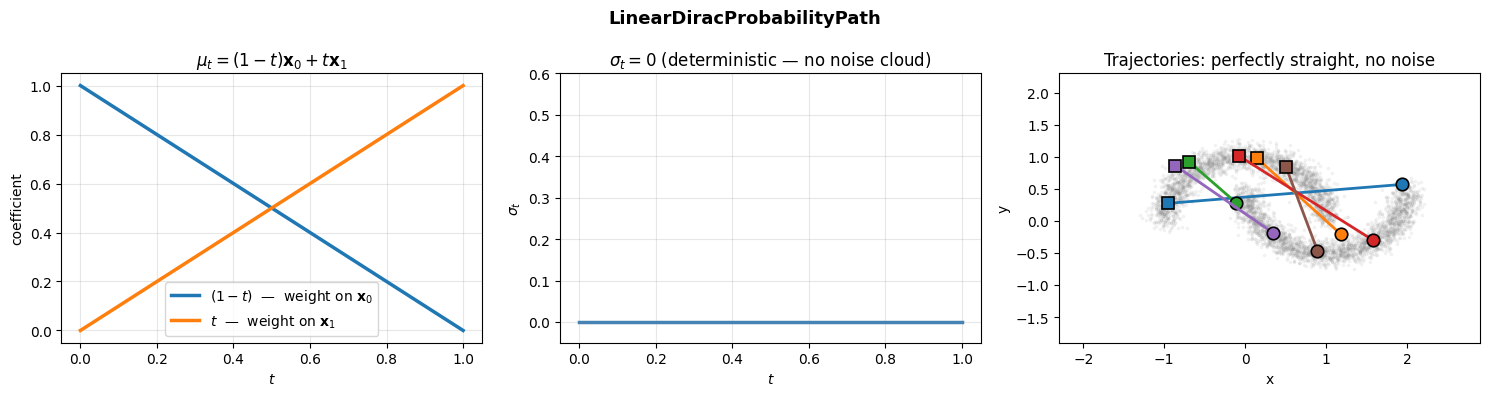

In [44]:
t_vals = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Left: interpolation coefficients ─────────────────────────────────────────
axes[0].plot(t_vals, 1 - t_vals, lw=2.5, color="tab:blue", label=r"$(1-t)$  —  weight on $\mathbf{x}_0$")
axes[0].plot(t_vals, t_vals, lw=2.5, color="tab:orange", label=r"$t$  —  weight on $\mathbf{x}_1$")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("coefficient")
axes[0].set_title(r"$\mu_t = (1-t)\mathbf{x}_0 + t\mathbf{x}_1$")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Middle: sigma_t ───────────────────────────────────────────────────────────
axes[1].plot(t_vals, np.zeros_like(t_vals), lw=2.5, color="steelblue")
axes[1].set_ylim(-0.05, 0.6)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\sigma_t$")
axes[1].set_title(r"$\sigma_t = 0$ (deterministic — no noise cloud)")
axes[1].grid(alpha=0.3)

# ── Right: sample trajectories ────────────────────────────────────────────────
torch.manual_seed(7)
n_pairs, T_STEPS = 6, torch.linspace(0, 1, 50)
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch, x1_batch = bottom_moon_X[src_idx], top_moon_X[tgt_idx]

path = LinearDiracProbabilityPath()
axes[2].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=3, alpha=0.07, color="gray")
axes[2].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=3, alpha=0.07, color="gray")
for i in range(n_pairs):
    color = plt.cm.tab10(i / 10)
    traj = [path.compute_mu_t(t * torch.ones(1), x0_batch[i : i + 1], x1_batch[i : i + 1]).numpy()[0] for t in T_STEPS]
    traj = np.array(traj)
    axes[2].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2)
    axes[2].plot(*x0_batch[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2)
    axes[2].plot(*x1_batch[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2)
axes[2].set_xlim(-2.3, 2.9)
axes[2].set_ylim(-1.9, 2.3)
axes[2].set_title("Trajectories: perfectly straight, no noise")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

plt.suptitle("LinearDiracProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. LinearGaussianProbabilityPath

Adds **constant Gaussian noise** on top of the linear interpolation.  The mean is
identical to `LinearDiracProbabilityPath`; the difference is a non-zero $\sigma_t$.

**Linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

**Noise standard deviation**

$$\sigma_t = \sigma \quad \text{(constant at every } t \text{)}$$

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1) = \mathbf{x}_1 - \mathbf{x}_0$$

The velocity is **still constant** — the noise samples $\mathbf{x}_t$ during training
but does not change the target the network must predict.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | *required* | Noise level $\sigma > 0$. Controls the constant-width cloud around the straight-line mean. Larger $\sigma$ regularises more but makes the loss noisier. |

> **References:** \[1\] Lipman et al. (2022) · \[3\] Tong et al. (2023, CFM)


The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.


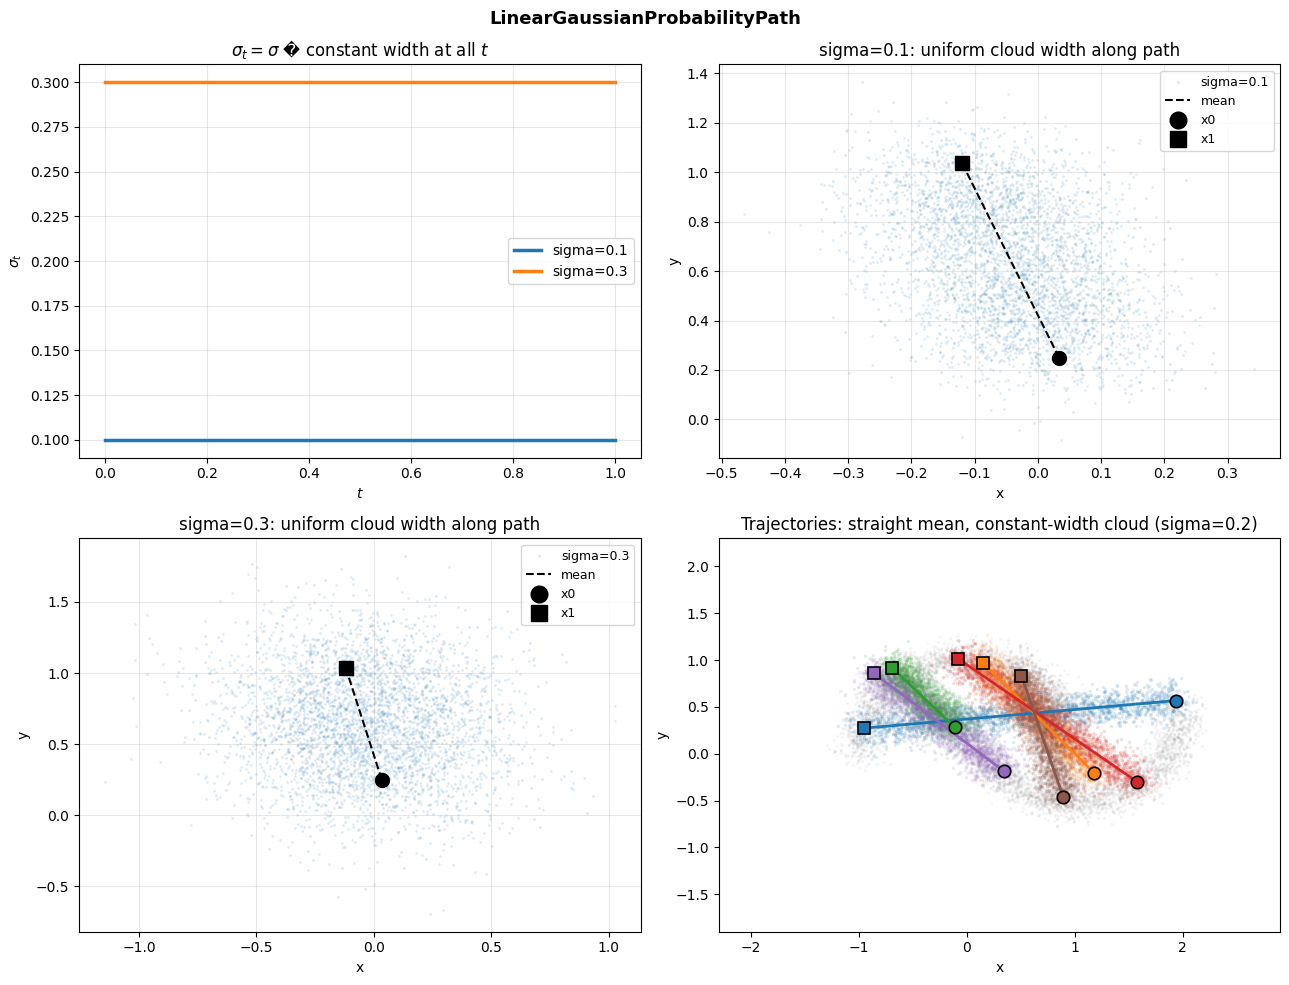

In [61]:
SIGMAS = [0.1, 0.3]
t_vals = np.linspace(0, 1, 200)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

# -- sigma_t profile
for sigma in SIGMAS:
    axes[0].plot(t_vals, np.full_like(t_vals, sigma), lw=2.5, label=f"sigma={sigma}")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sigma_t$")
axes[0].set_title(r"$\sigma_t = \sigma$ � constant width at all $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

# -- one cloud plot per sigma
torch.manual_seed(7)
x0 = bottom_moon_X[0:1]
x1 = top_moon_X[0:1]
T_STEPS, N_SAMPLES = torch.linspace(0, 1, 50), 80
mean_traj_single = np.array([((1 - t) * x0 + t * x1).numpy()[0] for t in T_STEPS])

for ax, sigma in zip(axes[1:3], SIGMAS, strict=False):
    path = LinearGaussianProbabilityPath(sigma=sigma)
    cloud = np.array(
        [path.compute_xt(t * torch.ones(1), x0, x1).detach().numpy()[0] for t in T_STEPS for _ in range(N_SAMPLES)]
    )
    ax.scatter(cloud[:, 0], cloud[:, 1], s=4, alpha=0.15, linewidths=0, label=f"sigma={sigma}")
    ax.plot(mean_traj_single[:, 0], mean_traj_single[:, 1], "k--", lw=1.5, label="mean")
    ax.plot(*x0.numpy()[0], "o", color="k", ms=10, markeredgecolor="k", zorder=5, label="x0")
    ax.plot(*x1.numpy()[0], "s", color="k", ms=10, markeredgecolor="k", zorder=5, label="x1")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"sigma={sigma}: uniform cloud width along path")
    ax.legend(fontsize=9, markerscale=1.2)
    ax.grid(alpha=0.3)

# -- trajectory plot: 6 pairs, mean lines + noise cloud (sigma=0.2)
torch.manual_seed(7)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch = bottom_moon_X[src_idx]
x1_batch = top_moon_X[tgt_idx]
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]
path_traj = LinearGaussianProbabilityPath(sigma=0.1)
axes[3].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=2, alpha=0.05, color="gray")
axes[3].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=2, alpha=0.05, color="gray")
for i in range(n_pairs):
    color = PAIR_COLORS[i]
    x0i = x0_batch[i : i + 1]
    x1i = x1_batch[i : i + 1]
    traj = np.array([path_traj.compute_mu_t(t * torch.ones(1), x0i, x1i).numpy()[0] for t in T_STEPS])
    cloud = np.array(
        [path_traj.compute_xt(t * torch.ones(1), x0i, x1i).detach().numpy()[0] for t in T_STEPS for _ in range(40)]
    )
    axes[3].scatter(cloud[:, 0], cloud[:, 1], s=6, color=color, alpha=0.15, linewidths=0)
    axes[3].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2, zorder=3)
    axes[3].plot(*x0_batch[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
    axes[3].plot(*x1_batch[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
axes[3].set_xlim(-2.3, 2.9)
axes[3].set_ylim(-1.9, 2.3)
axes[3].set_title("Trajectories: straight mean, constant-width cloud (sigma=0.2)")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")

plt.suptitle("LinearGaussianProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. SchrodingerBridgeProbabilityPath

The **Schrödinger Bridge** path shares the same linear mean as the two paths
above but uses a **time-varying noise** that vanishes at both endpoints.

**Linear interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1) = (1-t)\,\mathbf{x}_0 + t\,\mathbf{x}_1$$

**Noise standard deviation**

$$\sigma_t = \sigma\,\sqrt{t\,(1-t)}$$

The noise profile is a bell curve peaking at $t = \tfrac{1}{2}$ with
$\sigma_{1/2} = \tfrac{\sigma}{2}$, and $\sigma_0 = \sigma_1 = 0$.

**Conditional velocity field**

$$u_t(\mathbf{x}_t \mid \mathbf{x}_0, \mathbf{x}_1)
  = \frac{1-2t}{2t(1-t)+\varepsilon}\left(\mathbf{x}_t - \mu_t\right)
    + \mathbf{x}_1 - \mathbf{x}_0$$

Unlike the linear paths, $u_t$ depends on $\mathbf{x}_t$ itself: the first term
"corrects" for the current noise level and ensures the sampled $\mathbf{x}_t$
arrives exactly at $\mathbf{x}_1$ by $t = 1$.

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | *required* | Controls peak noise at the midpoint: $\sigma_{1/2} = \sigma/2$. |
| `eps` | `float` | `1e-35` | Added to the denominator $2t(1-t)$ to avoid division by zero near $t=0$ and $t=1$. Only change this if you observe numerical instability. |

> **References:** \[3\] Tong et al. (2023, CFM) · \[4\] Tong et al. (2023, SFBM)


The probability path  SchrodingerBridgeProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
The probability path  SchrodingerBridgeProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
The probability path  SchrodingerBridgeProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
The probability path  SchrodingerBridgeProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.
The probability path  SchrodingerBridgeProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.de

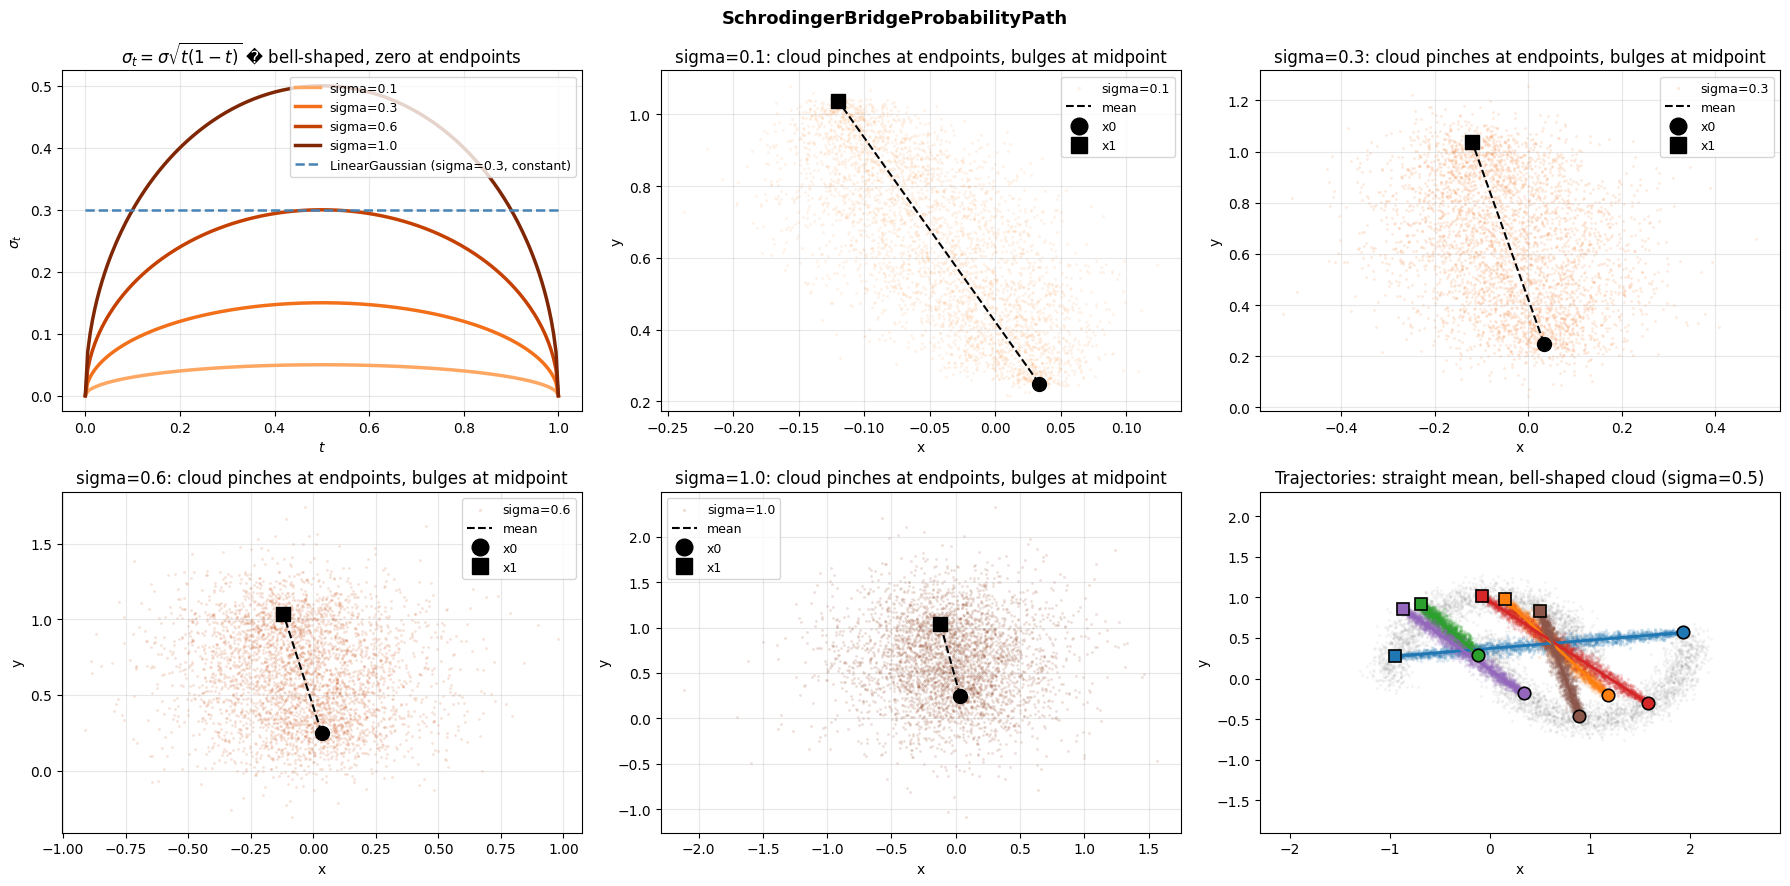

In [60]:
SIGMAS = [0.1, 0.3, 0.6, 1.0]
t_vals = np.linspace(0, 1, 200)
colors = plt.cm.Oranges(np.linspace(0.4, 1.0, len(SIGMAS)))

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# -- sigma_t profiles
for sigma, c in zip(SIGMAS, colors, strict=False):
    sigma_t = sigma * np.sqrt(t_vals * (1 - t_vals))
    axes[0].plot(t_vals, sigma_t, lw=2.5, color=c, label=f"sigma={sigma}")
axes[0].plot(
    t_vals,
    np.full_like(t_vals, 0.3),
    lw=1.8,
    color="steelblue",
    linestyle="--",
    label="LinearGaussian (sigma=0.3, constant)",
)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\sigma_t$")
axes[0].set_title(r"$\sigma_t = \sigma\sqrt{t(1-t)}$ � bell-shaped, zero at endpoints")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# -- one cloud plot per sigma
torch.manual_seed(7)
x0 = bottom_moon_X[0:1]
x1 = top_moon_X[0:1]
T_STEPS, N_SAMPLES = torch.linspace(0, 1, 50), 80
mean_traj_single = np.array([((1 - t) * x0 + t * x1).numpy()[0] for t in T_STEPS])

for ax, sigma, c in zip(axes[1:5], SIGMAS, colors, strict=False):
    path = SchrodingerBridgeProbabilityPath(sigma=sigma)
    cloud = np.array(
        [path.compute_xt(t * torch.ones(1), x0, x1).detach().numpy()[0] for t in T_STEPS for _ in range(N_SAMPLES)]
    )
    ax.scatter(cloud[:, 0], cloud[:, 1], s=4, color=c, alpha=0.15, linewidths=0, label=f"sigma={sigma}")
    ax.plot(mean_traj_single[:, 0], mean_traj_single[:, 1], "k--", lw=1.5, label="mean")
    ax.plot(*x0.numpy()[0], "o", color="k", ms=10, markeredgecolor="k", zorder=5, label="x0")
    ax.plot(*x1.numpy()[0], "s", color="k", ms=10, markeredgecolor="k", zorder=5, label="x1")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"sigma={sigma}: cloud pinches at endpoints, bulges at midpoint")
    ax.legend(fontsize=9, markerscale=1.2)
    ax.grid(alpha=0.3)

# -- trajectory plot: 6 pairs, mean lines + noise cloud (sigma=0.5)
torch.manual_seed(7)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch = bottom_moon_X[src_idx]
x1_batch = top_moon_X[tgt_idx]
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]
path_traj = SchrodingerBridgeProbabilityPath(sigma=0.1)
axes[5].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=2, alpha=0.05, color="gray")
axes[5].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=2, alpha=0.05, color="gray")
for i in range(n_pairs):
    color = PAIR_COLORS[i]
    x0i = x0_batch[i : i + 1]
    x1i = x1_batch[i : i + 1]
    traj = np.array([path_traj.compute_mu_t(t * torch.ones(1), x0i, x1i).numpy()[0] for t in T_STEPS])
    cloud = np.array(
        [path_traj.compute_xt(t * torch.ones(1), x0i, x1i).detach().numpy()[0] for t in T_STEPS for _ in range(40)]
    )
    axes[5].scatter(cloud[:, 0], cloud[:, 1], s=6, color=color, alpha=0.15, linewidths=0)
    axes[5].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2, zorder=3)
    axes[5].plot(*x0_batch[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
    axes[5].plot(*x1_batch[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2, zorder=5)
axes[5].set_xlim(-2.3, 2.9)
axes[5].set_ylim(-1.9, 2.3)
axes[5].set_title("Trajectories: straight mean, bell-shaped cloud (sigma=0.5)")
axes[5].set_xlabel("x")
axes[5].set_ylabel("y")

plt.suptitle("SchrodingerBridgeProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. VariancePreservingDiracProbabilityPath

A **deterministic path with a cosine interpolation blend**.  Instead of the
linear weights $(1-t)$ and $t$, the mean uses $\sin$ and $\cos$ coefficients that
trace a quarter-circle arc in coefficient space. n the method, there is no ditortion of the length of the path at any point.

**cosine interpolation**

$$\mu_t(\mathbf{x}_0, \mathbf{x}_1)
  = \cos\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_1
  + \sin\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_0$$

**Noise standard deviation**

$$\sigma_t = 0$$

**Conditional velocity field**

$$u_t = -\tfrac{\pi}{2}\sin\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_1
       + \tfrac{\pi}{2}\cos\!\left(\tfrac{\pi t}{2}\right)\mathbf{x}_0$$

**Parameters**

| Parameter | Type | Default | Description |
|---|---|---|---|
| `sigma` | `float` | `0.0` | Accepted but **ignored** — `compute_sigma_t` always returns 0 regardless of this value. |

> **Note on time convention:** at $t=0$, $\mu_0 = \mathbf{x}_1$ (target); at $t=1$,
> $\mu_1 = \mathbf{x}_0$ (source).  The path runs in the *reverse* direction
> compared to the three paths above — keep this in mind when comparing trajectories.

> **References:** \[5\] Albergo & Vanden-Eijnden (2022) · \[6\] Song et al. (2020)


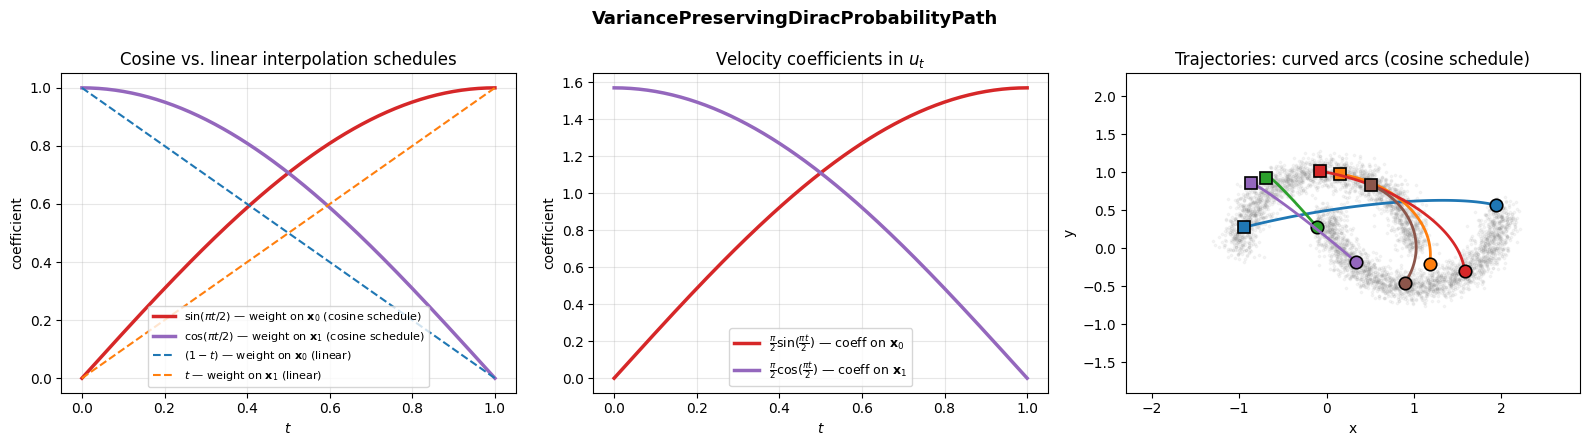

In [47]:
t_vals = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── Left: cosine vs linear interpolation coefficients ────────────────────────
axes[0].plot(
    t_vals,
    np.sin(0.5 * np.pi * t_vals),
    lw=2.5,
    color="tab:red",
    label=r"$\sin(\pi t/2)$ — weight on $\mathbf{x}_0$ (cosine schedule)",
)
axes[0].plot(
    t_vals,
    np.cos(0.5 * np.pi * t_vals),
    lw=2.5,
    color="tab:purple",
    label=r"$\cos(\pi t/2)$ — weight on $\mathbf{x}_1$ (cosine schedule)",
)
axes[0].plot(
    t_vals, 1 - t_vals, lw=1.5, color="tab:blue", linestyle="--", label=r"$(1-t)$ — weight on $\mathbf{x}_0$ (linear)"
)
axes[0].plot(
    t_vals, t_vals, lw=1.5, color="tab:orange", linestyle="--", label=r"$t$ — weight on $\mathbf{x}_1$ (linear)"
)
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("coefficient")
axes[0].set_title("Cosine vs. linear interpolation schedules")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Middle: velocity field magnitude ─────────────────────────────────────────
# |u_t|² = (π/2)² * (sin²(πt/2) |x_1|² + cos²(πt/2) |x_0|²)  for orthogonal pair
# show the scalar coefficients π/2 * sin(πt/2) and π/2 * cos(πt/2)
axes[1].plot(
    t_vals,
    0.5 * np.pi * np.sin(0.5 * np.pi * t_vals),
    lw=2.5,
    color="tab:red",
    label=r"$\frac{\pi}{2}\sin(\frac{\pi t}{2})$ — coeff on $\mathbf{x}_0$",
)
axes[1].plot(
    t_vals,
    0.5 * np.pi * np.cos(0.5 * np.pi * t_vals),
    lw=2.5,
    color="tab:purple",
    label=r"$\frac{\pi}{2}\cos(\frac{\pi t}{2})$ — coeff on $\mathbf{x}_1$",
)
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("coefficient")
axes[1].set_title(r"Velocity coefficients in $u_t$")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ── Right: curved trajectories ────────────────────────────────────────────────
torch.manual_seed(7)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch, x1_batch = bottom_moon_X[src_idx], top_moon_X[tgt_idx]

path = VariancePreservingDiracProbabilityPath()
axes[2].scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=3, alpha=0.07, color="gray")
axes[2].scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=3, alpha=0.07, color="gray")
T_STEPS = torch.linspace(0, 1, 50)
for i in range(n_pairs):
    color = plt.cm.tab10(i / 10)
    traj = np.array(
        [path.compute_mu_t(t * torch.ones(1), x0_batch[i : i + 1], x1_batch[i : i + 1]).numpy()[0] for t in T_STEPS]
    )
    axes[2].plot(traj[:, 0], traj[:, 1], "-", color=color, lw=2)
    # t=0 → x1 (target), t=1 → x0 (source); mark accordingly
    axes[2].plot(*x0_batch[i].numpy(), "o", color=color, ms=9, markeredgecolor="k", mew=1.2)
    axes[2].plot(*x1_batch[i].numpy(), "s", color=color, ms=9, markeredgecolor="k", mew=1.2)
axes[2].set_xlim(-2.3, 2.9)
axes[2].set_ylim(-1.9, 2.3)
axes[2].set_title("Trajectories: curved arcs (cosine schedule)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

plt.suptitle("VariancePreservingDiracProbabilityPath", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Side-by-Side Comparison

The plots below show **6 random (source, target) pairs** for each path.

- **Solid line** — mean trajectory $\mu_t$
- **Scatter cloud** — individual noisy samples $\mathbf{x}_t$ (stochastic paths only)
- **Circle** — source point $\mathbf{x}_0$, **Square** — target point $\mathbf{x}_1$


<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_15968\3310517769.py:58: SyntaxWarning: invalid escape sequence '\m'
  markeredgecolor="k", ms=10, label="Source $\mathbf{x}_0$ (circle)"),
C:\Users\HP\AppData\Local\Temp\ipykernel_15968\3310517769.py:60: SyntaxWarning: invalid escape sequence '\m'
  markeredgecolor="k", ms=10, label="Target $\mathbf{x}_1$ (square)"),
C:\Users\HP\AppData\Local\Temp\ipykernel_15968\3310517769.py:61: SyntaxWarning: invalid escape sequence '\m'
  Line2D([0], [0], color="gray", lw=2.5, label="Mean trajectory $\mu_t$"),
C:\Users\HP\AppData\Local\Temp\ipykernel_15968\3

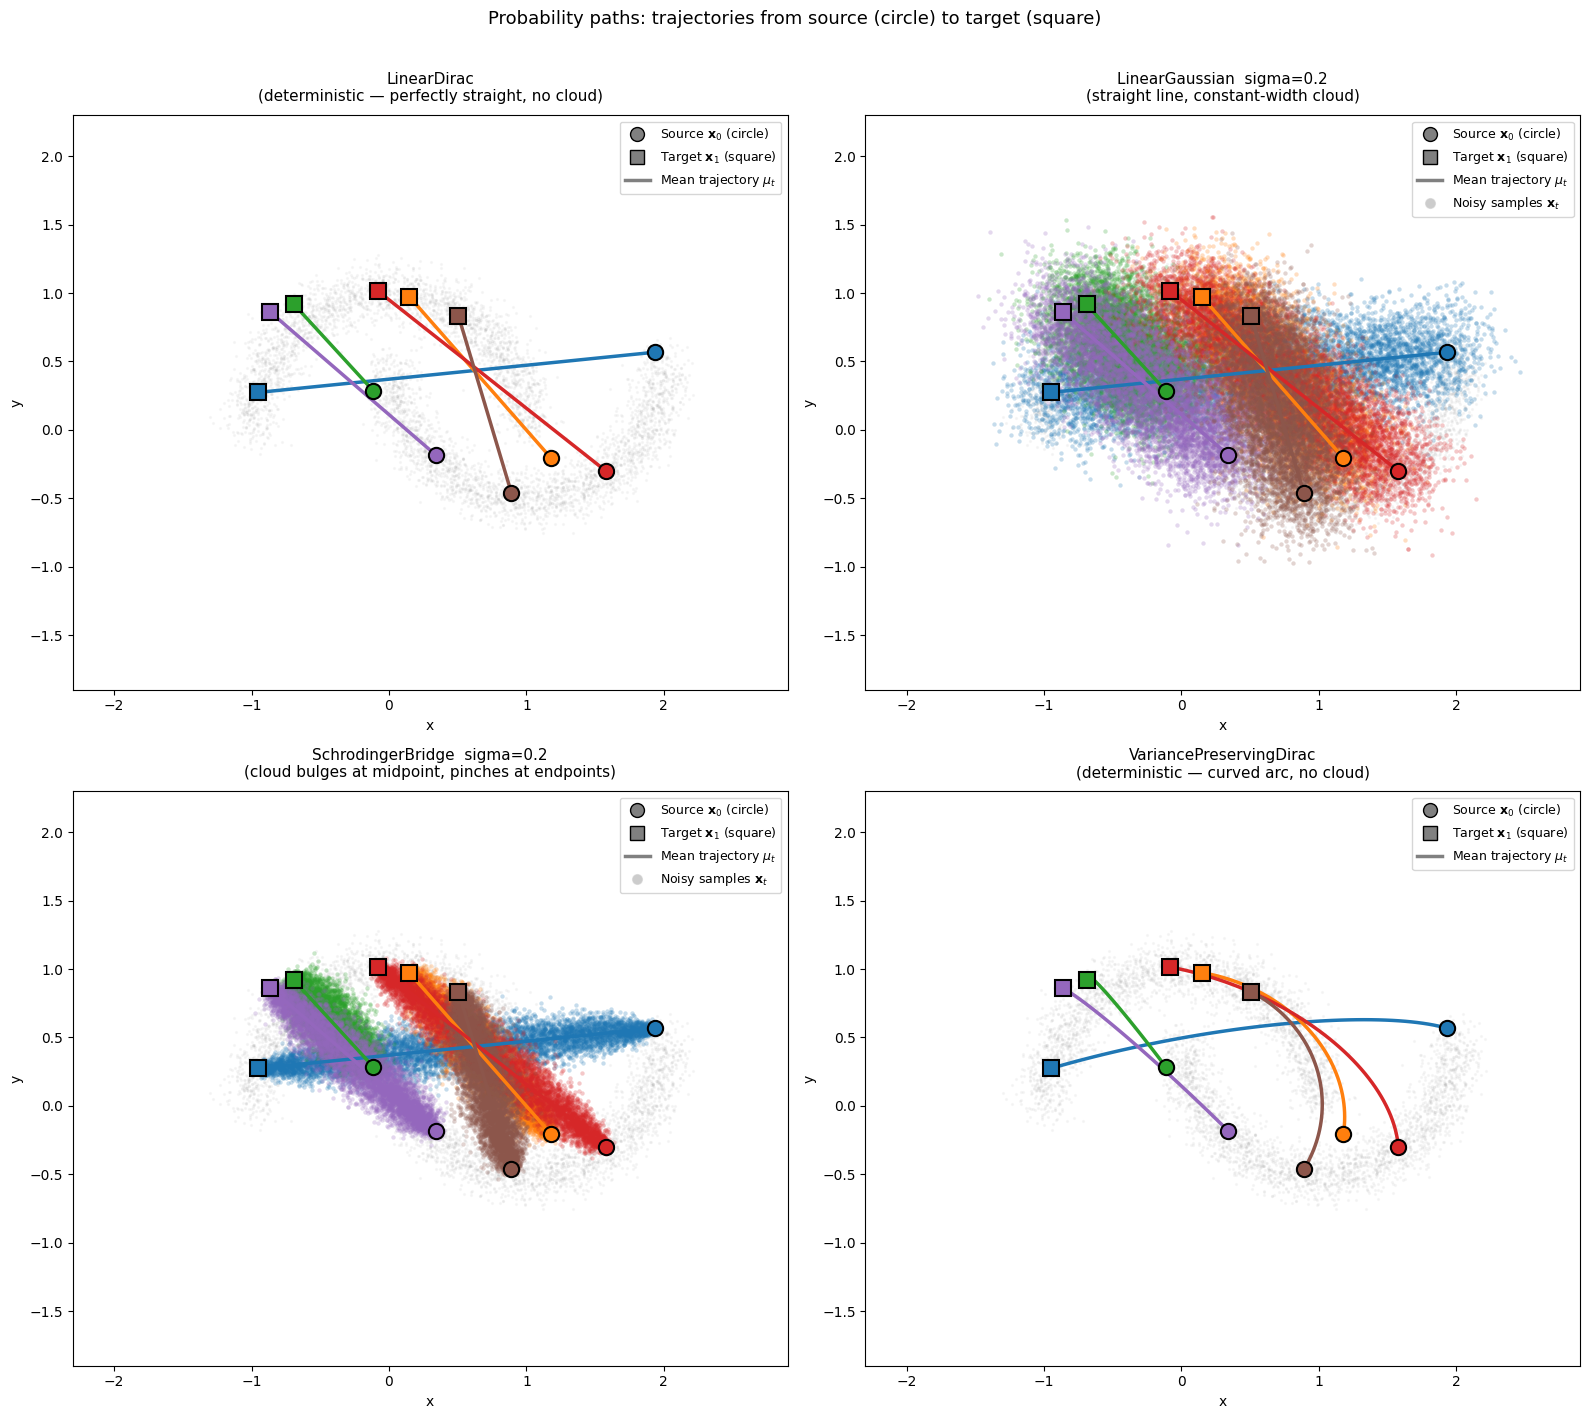

In [62]:
torch.manual_seed(7)
n_pairs = 6
src_idx = torch.randperm(len(bottom_moon_X))[:n_pairs]
tgt_idx = torch.randperm(len(top_moon_X))[:n_pairs]
x0_batch = bottom_moon_X[src_idx]
x1_batch = top_moon_X[tgt_idx]

T_STEPS = torch.linspace(0, 1, 50)
N_NOISE_SAMPLES = 150
PAIR_COLORS = [plt.cm.tab10(i / 10) for i in range(n_pairs)]

VIZ_PATHS = [
    ("LinearDirac\n(deterministic — perfectly straight, no cloud)", LinearDiracProbabilityPath()),
    ("LinearGaussian  sigma=0.2\n(straight line, constant-width cloud)", LinearGaussianProbabilityPath(sigma=0.2)),
    (
        "SchrodingerBridge  sigma=0.2\n(cloud bulges at midpoint, pinches at endpoints)",
        SchrodingerBridgeProbabilityPath(sigma=0.2),
    ),
    ("VariancePreservingDirac\n(deterministic — curved arc, no cloud)", VariancePreservingDiracProbabilityPath()),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for ax, (title, path) in zip(axes, VIZ_PATHS, strict=False):
    ax.scatter(bottom_moon_X[:, 0], bottom_moon_X[:, 1], s=2, alpha=0.05, color="gray", zorder=1)
    ax.scatter(top_moon_X[:, 0], top_moon_X[:, 1], s=2, alpha=0.05, color="gray", zorder=1)

    for i in range(n_pairs):
        color = PAIR_COLORS[i]
        x0 = x0_batch[i : i + 1]
        x1 = x1_batch[i : i + 1]

        mean_traj = np.array([path.compute_mu_t(t * torch.ones(1), x0, x1).detach().numpy()[0] for t in T_STEPS])
        noise_pts = []
        if path._require_prng:
            noise_pts = np.array(
                [
                    path.compute_xt(t * torch.ones(1), x0, x1).detach().numpy()[0]
                    for t in T_STEPS
                    for _ in range(N_NOISE_SAMPLES)
                ]
            )

        if len(noise_pts):
            ax.scatter(noise_pts[:, 0], noise_pts[:, 1], s=10, color=color, alpha=0.25, zorder=2, linewidths=0)

        ax.plot(mean_traj[:, 0], mean_traj[:, 1], "-", color=color, lw=2.5, zorder=3)
        ax.plot(*x0_batch[i].numpy(), "o", color=color, ms=11, markeredgecolor="k", markeredgewidth=1.5, zorder=5)
        ax.plot(*x1_batch[i].numpy(), "s", color=color, ms=11, markeredgecolor="k", markeredgewidth=1.5, zorder=5)

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="gray",
            markeredgecolor="k",
            ms=10,
            label=r"Source $\mathbf{x}_0$ (circle)",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor="gray",
            markeredgecolor="k",
            ms=10,
            label=r"Target $\mathbf{x}_1$ (square)",
        ),
        Line2D([0], [0], color="gray", lw=2.5, label=r"Mean trajectory $\mu_t$"),
    ]
    if path._require_prng:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="gray",
                alpha=0.4,
                ms=8,
                label=r"Noisy samples $\mathbf{x}_t$",
            )
        )
    ax.legend(handles=legend_handles, fontsize=9, loc="upper right")
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlim(-2.3, 2.9)
    ax.set_ylim(-1.9, 2.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Probability paths: trajectories from source (circle) to target (square)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## References

\[1\] Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., Nickel, M., & Le, M. (2022).
**Flow Matching for Generative Modeling.** *ICLR 2023.*
[https://arxiv.org/abs/2210.02747](https://arxiv.org/abs/2210.02747)

\[2\] Liu, X., Gong, C., & Liu, Q. (2022).
**Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow.** *ICLR 2023.*
[https://arxiv.org/abs/2209.03003](https://arxiv.org/abs/2209.03003)

\[3\] Tong, A., Malkin, N., Huguet, G., Zhang, Y., Rector-Brooks, J., Fatras, K., Wolf, G., & Bengio, Y. (2023).
**Improving and Generalizing Flow-Matching for Conditional Generation (CFM).** *ICML 2024.*
[https://arxiv.org/abs/2302.00482](https://arxiv.org/abs/2302.00482)

\[4\] Tong, A., De Bortoli, V., Doucet, A., & Durmus, A. (2023).
**Simulation-Free Schrödinger Bridges via Score and Flow Matching (SFBM).**
[https://arxiv.org/abs/2307.03672](https://arxiv.org/abs/2307.03672)

\[5\] Albergo, M. S., & Vanden-Eijnden, E. (2022).
**Building Normalizing Flows with Stochastic Interpolants.** *ICLR 2023.*
[https://arxiv.org/abs/2209.15571](https://arxiv.org/abs/2209.15571)

\[6\] Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2020).
**Score-Based Generative Modeling through Stochastic Differential Equations (VP-SDE).** *ICLR 2021.*
[https://arxiv.org/abs/2011.13456](https://arxiv.org/abs/2011.13456)
